**PREPARATION AND ANALYSIS OF SIESTA SIMULATIONS WITH PYTHON**
--------------------------------------------------------------

Using the pythin libray sisl, we can prepare simulations for SIESTA and analyze results.
This notebook is based on the tutorials available here:

https://sisl.readthedocs.io/en/latest/tutorials/index.html#siesta-transiesta-support


Setup
-----
We first import all required libraries

In [1]:
from sisl import *
import numpy as np
import matplotlib.pyplot as plt

Visualization of a structure
----------------------------
Example of loading and visualization of a fdf file with coordinates. 

In [2]:
system = Geometry.read("./RUN.fdf")

In [3]:
system.plot()

/home/jordi/.conda/envs/siesta/lib/python3.13/site-packages/sisl/viz/processors/xarray.py:208: FutureWarning:

Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sc_atom'} to avoid an error in the future.



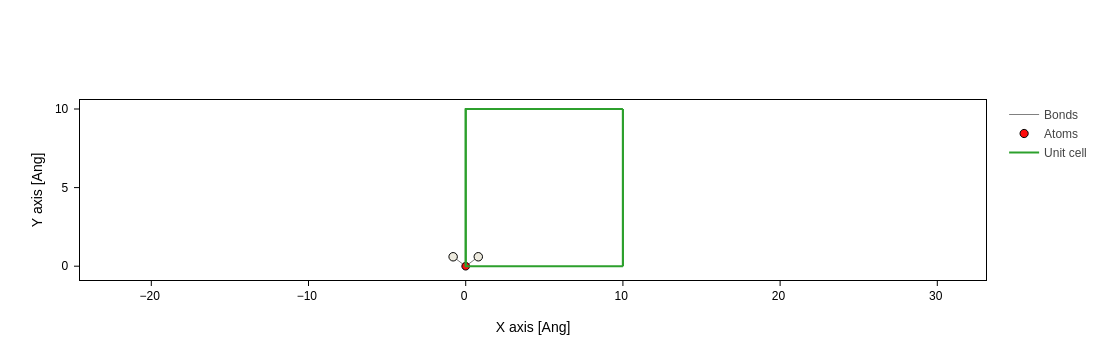

In [4]:
system.plot(axes="xy")

## Analysis of SIESTA Results
**Load SIESTA Calculation**

Once the SIESTA run has finished, to load SIESTA results into python you can use the following sisl command:

```python
get_sile("path/to/my/file.fdf").read_hamiltonian()
```

This will read the Hamiltonian with all the information of the system corresponding to this Hamiltonian

In [4]:
fdf = get_sile("RUN.fdf")

In [5]:
H = fdf.read_hamiltonian()

In [6]:
print(H)

Hamiltonian{non-zero: 418830, orthogonal: False,
 Spin{unpolarized},
 Geometry{na: 60, no: 780,
  Atoms{species: 1,
   Atom{C, Z: 6, mass(au): 12.01100, maxR: 3.30951,
    AtomicOrbital{2sZ1, q0: 2.0, SphericalOrbital{l: 0, R: 2.6548991702149065, q0: 2.0}},
    AtomicOrbital{2sZ2, q0: 0.0, SphericalOrbital{l: 0, R: 1.6858398488354462, q0: 0.0}},
    AtomicOrbital{2pyZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260040147, q0: 2.0}},
    AtomicOrbital{2pzZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260040147, q0: 2.0}},
    AtomicOrbital{2pxZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260040147, q0: 2.0}},
    AtomicOrbital{2pyZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003493, q0: 0.0}},
    AtomicOrbital{2pzZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003493, q0: 0.0}},
    AtomicOrbital{2pxZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003493, q0: 0.0}},
    AtomicOrbital{3dxyZ1P, q0: 0.0, SphericalOrbital{l: 2, R: 3.309

**Show Data employed in the calculation**

Before analysing the diagonalisation of H, we can show the geometry of the system and the basis set employed

In [7]:
system = H.geometry

In [8]:
system.plot(axes="xy")

In [11]:
# FUNCTION PLOT ORBITALS
def plot_atom(atom):
    no = len(atom) # number of orbitals
    nx = no // 4
    ny = no // nx
    if nx * ny < no:
        nx += 1
    fig, axs = plt.subplots(nx, ny, figsize=(20, 5*nx))
    fig.suptitle('Atom: {}'.format(atom.symbol), fontsize=14)
    def my_plot(i, orb):
            grid = orb.toGrid(atom=atom)
            # Also write to a cube file
            grid.write('{}_{}.cube'.format(atom.symbol, orb.name()))
            c, r = i // 4, (i - 4) % 4
            if nx == 1:
                ax = axs[r]
            else:
                ax = axs[c][r]
            ax.imshow(grid.grid[:, :, grid.shape[2] // 2])
            ax.set_title(r'${}$'.format(orb.name(True)))
            ax.set_xlabel(r'$x$ [Ang]')
            ax.set_ylabel(r'$y$ [Ang]')
    i = 0
    for orb in atom:
            my_plot(i, orb)
            i += 1
    if i < nx * ny:
            # This removes the empty plots
            for j in range(i, nx * ny):
                c, r = j // 4, (j - 4) % 4
                if nx == 1:
                    ax = axs[r]
                else:
                    ax = axs[c][r]
                fig.delaxes(ax)
            plt.draw()

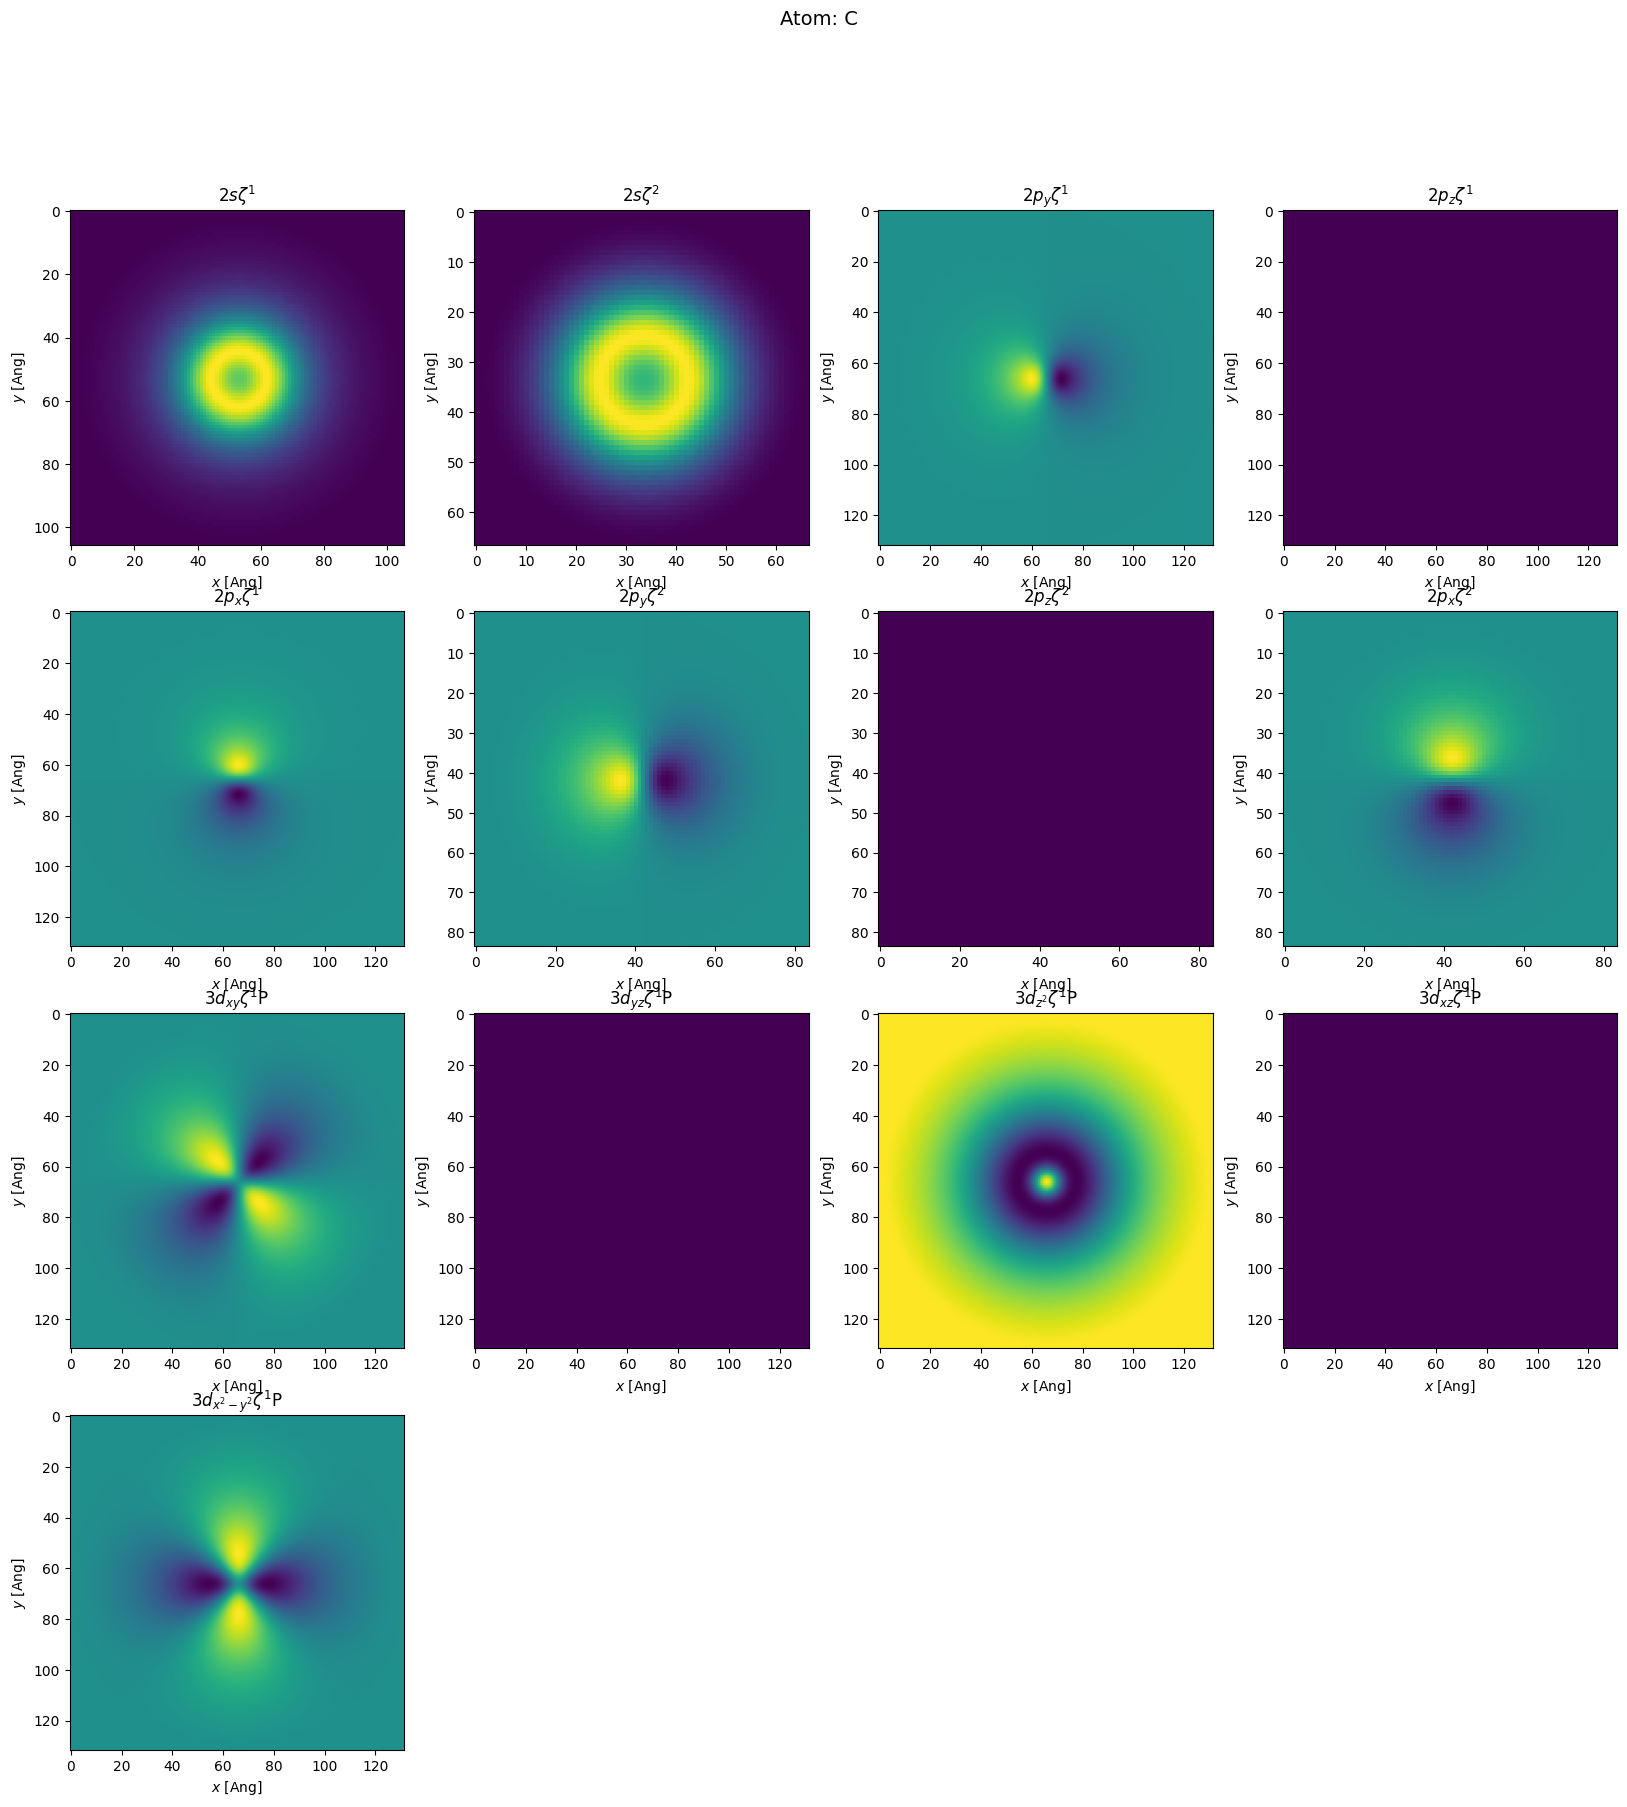

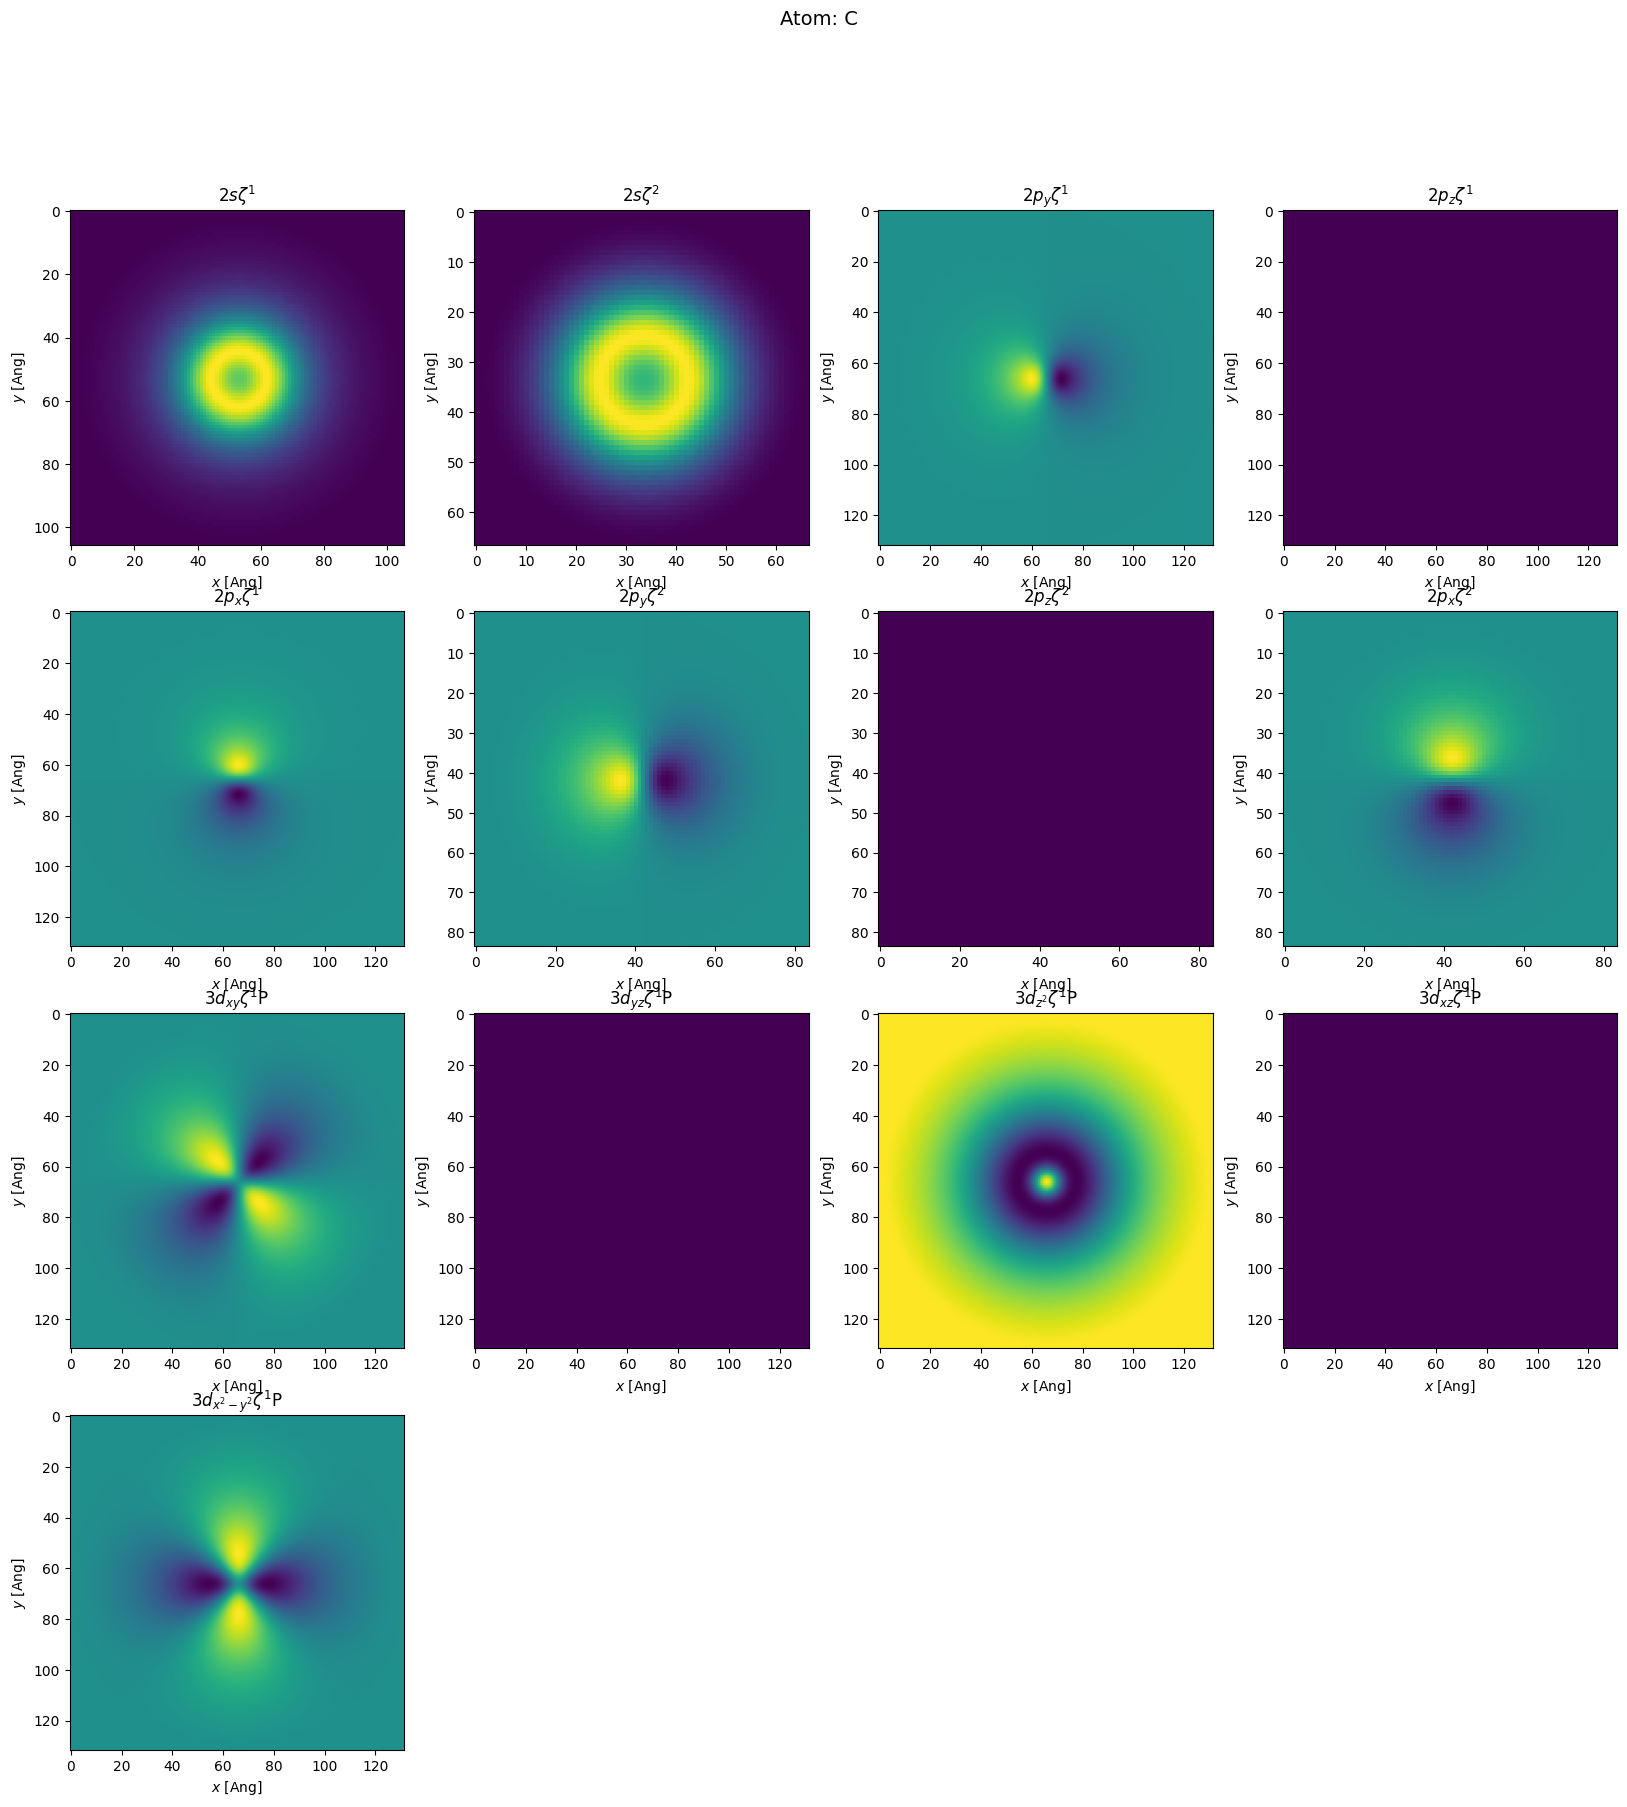

In [12]:
plot_atom(system.atoms[0])
plot_atom(system.atoms[1])
plt.show()

## Eigenstates

Once you have a hamiltonian, you can get all Eigenstates with `H.eigenstate()`. Then you can loop this object to get each individual eigenstate. 
- Each eigenstate has its energy stored under the `.eig` property.
- We can find the HOMO and LUMO.
- We can use the `.dos`  method to obtain the density of states DOS(E).
- In sisl we can plot pdos directly in a given Energy range with something like `H.plot.pdos(data_Erange=[-10,10],nE=1200,Erange=[-10,10]) `

In [13]:
es=H.eigenstate()

In [14]:
es.eig

array([-17.01909909, -16.63281527, -16.62564271, -16.62383587,
       -15.89340179, -15.88639517, -15.88068881, -15.8776722 ,
       -15.8708432 , -15.19457864, -15.18868034, -15.17974138,
       -14.24497093, -14.23341232, -14.22753644, -14.21083371,
       -13.33928826, -13.32796037, -13.32324472, -13.31057918,
       -13.30088033, -12.94195192, -12.93095136, -12.91706883,
       -12.90552439, -11.9572821 , -11.95229564, -11.94467317,
       -11.94138594, -11.9285915 , -11.45923804, -11.44003554,
       -11.42514301, -10.13594004, -10.11780741, -10.09172207,
        -9.9851326 ,  -9.97550938,  -9.97176637,  -9.4931778 ,
        -9.49098625,  -9.48052183,  -9.460764  ,  -9.45491422,
        -8.14407292,  -7.88806172,  -7.87934555,  -7.87315489,
        -7.86185733,  -7.84645231,  -7.83830983,  -7.8248685 ,
        -7.81958152,  -7.79830919,  -6.80125579,  -6.78876362,
        -6.78518372,  -6.01948995,  -6.00715404,  -6.00667596,
        -5.99584281,  -5.98680315,  -5.98054121,  -5.97

In [15]:
idx_lumo = (es.eig > 0).nonzero()[0][0] #trick to obtain the LUMO as first positive eigenvalue
idx_homo = idx_lumo-1

In [16]:
print(idx_lumo)

120


In [17]:
print("HOMO E=",es.eig[idx_homo]," eV")
print("LUMO E=",es.eig[idx_lumo]," eV")

HOMO E= -0.5370867161013474  eV
LUMO E= 0.5207515730175964  eV


-----------------------------------------------------------------------------------
## Exporting Wavefunctions for 3D plotting

Create a grid and fill the grid with the probability density. The result can be sved in .cube format:

https://paulbourke.net/dataformats/cube/


**To compute wavefunctions on the grid:**

To compute $\psi (\vec{r})$ you need three things.

1. **The eigenstate coefficients.** Once you have a hamiltonian, you can get all of them with `H.eigenstate()`. Then you can loop this object to get each individual eigenstate. Each eigenstate has its energy stored under the `.eig` property.
2. **A grid of points in space.** You can create one with `sisl.Grid(geometry, shape=(100, 100, 100))`. This will create a grid of $100x100x100$ points within the cell of your geometry.
3. **A function to project the wavefunction into the grid.** The eigenstate object has a `wavefunction` method ([docs](https://zerothi.github.io/sisl/api/generated/sisl.physics.electron.EigenstateElectron.html#sisl.physics.electron.EigenstateElectron.wavefunction)) that will project the wavefunction into an already initialized grid.
4. Once you have the wavefunction, you can calculate the electron density $\psi_i(\vec{r}) \psi_i^*(\vec{r})$.
5. The result can be saved in a '.cube' file and plotted with VMD 

This can always be done as in our first SIESTA lab, with a water molecule and with $C_{60}$.


In [19]:
system.lattice.origin = [-4, -4, -4]
g = Grid(0.2, lattice=system.lattice)  #defines a grid matching with our system

Save desired states (for example, HOMO and LUMO) in cube file

In [20]:
es[idx_homo].wavefunction(g)
g.write('HOMO.cube')
print('Real space integrated wavefunction: {:.4f}'.format((np.absolute(g.grid) ** 2).sum() * g.dvolume))
g.fill(0) # reset the grid values to 0

info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


Real space integrated wavefunction: 1.0000


In [21]:
es[idx_lumo].wavefunction(g)
g.write('LUMO.cube')
print('Real space integrated wavefunction: {:.4f}'.format((np.absolute(g.grid) ** 2).sum() * g.dvolume))
g.fill(0) # reset the grid values to 0

info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


Real space integrated wavefunction: 1.0000


Save Electron Density

In [22]:
g2 = Grid(0.2, lattice=system.lattice) 

In [23]:
es[idx_lumo].wavefunction(g)
g2=g*g.grid.conj() 
g2.write('LUMOdens.cube')
g2.fill(0) # reset the grid values to 0

info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


We can easily save the electron density including a range of states

In [24]:
Gt = Grid(0.2, lattice=system.lattice) 
for n in range(idx_lumo-4,idx_lumo):
    print("adding state",n)
    g.fill(0)
    es[n].wavefunction(g)
    Gt = Gt + g*g.grid.conj()
Gt.write('several_states.cube')
Gt.fill(0)

    

adding state 116


info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


adding state 117


info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


adding state 118


info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


adding state 119


info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information
